## Part 1: Classification for Customer Purchase
<br>
Banks can generate significant profits from term deposits such as a certificate of deposit (CD). These deposits are required to be held for a certain period of time, which gives the bank access to those funds for lending purposes at a higher rate than the rate paid for the deposit. Of course, marketing term deposit products to customers can be expensive, so the bank will want to focus their efforts on those customers most likely to buy these products.<br>
<br>
In this data set, we have information about 45,211 customers, including demographic information as well as data related to their prior experience with the bank and previous marketing campaigns.Additionally, we have a class variable "y" that indicates whether this customer purchased a term product in the most recent marketing campaign.  Our objective is to predict which customers will purchase a term product if we spend the money to advertise to them.  We want to develop a model that will maximize the returns based on the costs of marketing and the benefits of customer purchase. <br>
<br>
This data was from a paper published by Moro et al. (S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014)
<br><br>
VARIABLE DESCRIPTIONS:<br>
1 - age (numeric) <br>
2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", "blue-collar","self-employed","retired","technician","services") <br>
3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed) <br>
4 - education (categorical: "unknown","secondary","primary","tertiary") <br>
5 - default: has credit in default? (categorical: "yes","no") <br>
6 - balance: average yearly balance, in euros (numeric) <br>
7 - housing: has housing loan? (categorical: "yes","no") <br>
8 - loan: has personal loan? (categorical: "yes","no") <br>
9 - contact: contact communication type (categorical: "unknown","telephone","cellular") <br>
10 - day: last contact day of the month (numeric) <br>
11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec") <br>
12 - duration: last contact duration, in seconds (numeric) <br>
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact) <br>
14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted) <br>
15 - previous: number of contacts performed before this campaign and for this client (numeric) <br>
16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success") <br>

<br>
TARGET VARIABLE - y: has the client subscribed a term deposit? (binary: "yes","no")
<br>
The target variable is y.  All other columns are potential predictors.

### 1.Upload and clean data

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Read data
bank = pd.read_csv('/content/drive/MyDrive/DL_data/bank.csv')
bank

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
# Examine the number of rows and cols
bank.shape

(45211, 17)

In [ ]:
# Show the head rows of a data frame
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Examine variable type
bank.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [ ]:
# Change categorical variables to "category"
bank['job'] = bank['job'].astype('category')
bank['marital'] = bank['marital'].astype('category')
bank['education'] = bank['education'].astype('category')
bank['default'] = bank['default'].astype('category')
bank['housing'] = bank['housing'].astype('category')
bank['loan'] = bank['loan'].astype('category')
bank['contact'] = bank['contact'].astype('category')
bank['month'] = bank['month'].astype('category')
bank['poutcome'] = bank['poutcome'].astype('category')
bank['y'] = bank['y'].astype('category')

In [ ]:
# Examine variable type again
bank.dtypes

age             int64
job          category
marital      category
education    category
default      category
balance         int64
housing      category
loan         category
contact      category
day             int64
month        category
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome     category
y            category
dtype: object

In [ ]:
# Display all numeric variables
bank.select_dtypes(include=['number'])

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


In [ ]:
# Display all categorical variables
bank.select_dtypes(include=['category'])

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,unknown,single,unknown,no,no,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown,yes
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown,yes
45208,retired,married,secondary,no,no,no,cellular,nov,success,yes
45209,blue-collar,married,secondary,no,no,no,telephone,nov,unknown,no


### 2.Data exploration (5 points)

Text(0.5, 1.0, 'countplot of y in the bank data set')

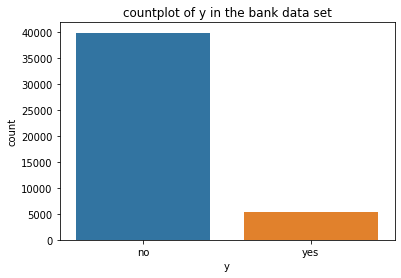

In [ ]:
# Show countplot of target variable (0.5 points)
snsplot = sns.countplot(x='y', data=bank)
snsplot.set_title("countplot of y in the bank data set")

Text(0.5, 1.0, 'countplot of housing in the bank data set')

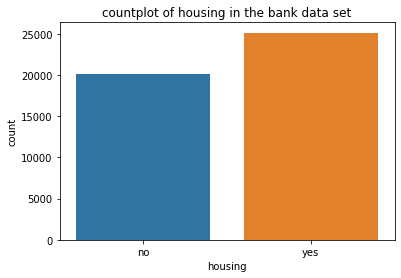

In [ ]:
# Show countplot of housing variable (0.5 points)
snsplot = sns.countplot(x='housing', data=bank)
snsplot.set_title("countplot of housing in the bank data set")

In [ ]:
# For housing variable, show the number of instances (count) in each category (0.5 points)
bank['housing'].value_counts()

yes    25130
no     20081
Name: housing, dtype: int64

Q1. How many customers have housing loans? (0.5 points)<br>
25130 customers have hosing loans

In [ ]:
# For job variable, show the number of instances (count) in each category (0.5 points)
bank['job'].value_counts()

blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: job, dtype: int64

Q2. How many customers are retired? (0.5 points)<br>
2264 customers are retired

Text(0.5, 1.0, 'Histogram of duration in the bank data set')

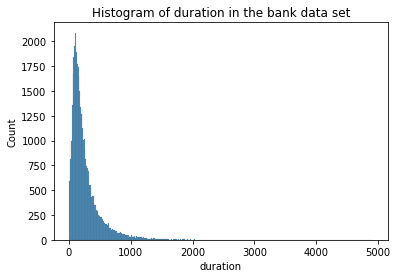

In [ ]:
# Show histogram of duration variable (0.5 points)
snsplot = sns.histplot(x='duration', data = bank)
snsplot.set_title("Histogram of duration in the bank data set")

Q3. Is the distribution (of duration variable) skewed? (0.5 points)<br>
It is right skewed.

In [ ]:
# Display correlation coefficient between age and balance variables. (0.5 points)
bank[['age','balance']].corr()

,age,balance
age,1.000000,0.097783
balance,0.097783,1.000000


Text(0.5, 1.0, 'Boxplot of duration based on y')

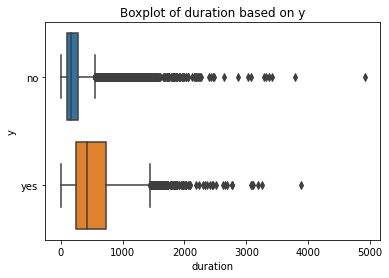

In [ ]:
# Show a boxplot of duration based on the value of y variable (y = yes or no). (0.5 points)
snsplot = sns.boxplot(x='duration', y= 'y', data = bank)
snsplot.set_title("Boxplot of duration based on y")

### 3.Data partitioning and inspection code (3.5 points)

In [ ]:
# Create dummy variables for all categorical variables, except the target variable	(1 point)
bank = pd.get_dummies(bank, columns=['job','marital','education','default','housing','loan','contact','month','poutcome'], drop_first=True)
bank

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,no,0,0,...,0,0,0,1,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,no,0,0,...,0,0,0,1,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,no,0,1,...,0,0,0,1,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,no,1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,no,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,yes,0,0,...,0,0,0,0,1,0,0,0,0,1
45207,71,1729,17,456,2,-1,0,yes,0,0,...,0,0,0,0,1,0,0,0,0,1
45208,72,5715,17,1127,5,184,3,yes,0,0,...,0,0,0,0,1,0,0,0,1,0
45209,57,668,17,508,4,-1,0,no,1,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
# Partition the data to predictors_train, predictors_test, target_train, and target_test. Set test_size=0.3 and random_state=0. (1.5 points)
target = bank['y']
predictors = bank.drop(['y'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(31647, 42) (13564, 42) (31647,) (13564,)


In [ ]:
# Examine the proportion of target variable for training data set (0.5 points)
print(target_train.value_counts(normalize=True))

no     0.883275
yes    0.116725
Name: y, dtype: float64


In [ ]:
# Examine the proportion of target variable for testing data set (0.5 points)
print(target_test.value_counts(normalize=True))

no     0.882409
yes    0.117591
Name: y, dtype: float64


### 4.Simple decision tree training and testing. (6.5 points)

In [ ]:
# Build a decision tree model on training data. Set criterion = "entropy", random_state = 1, max_depth = 3 (1 point)
model = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
model.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

[Text(0.5, 0.875, 'duration <= 452.5\nentropy = 0.52\nsamples = 31647\nvalue = [27953, 3694]\nclass = no'),
 Text(0.25, 0.625, 'poutcome_success <= 0.5\nentropy = 0.367\nsamples = 27177\nvalue = [25267, 1910]\nclass = no'),
 Text(0.125, 0.375, 'contact_unknown <= 0.5\nentropy = 0.299\nsamples = 26346\nvalue = [24948, 1398]\nclass = no'),
 Text(0.0625, 0.125, 'entropy = 0.378\nsamples = 18471\nvalue = [17116, 1355]\nclass = no'),
 Text(0.1875, 0.125, 'entropy = 0.049\nsamples = 7875\nvalue = [7832, 43]\nclass = no'),
 Text(0.375, 0.375, 'duration <= 129.5\nentropy = 0.961\nsamples = 831\nvalue = [319, 512]\nclass = yes'),
 Text(0.3125, 0.125, 'entropy = 0.759\nsamples = 155\nvalue = [121, 34]\nclass = no'),
 Text(0.4375, 0.125, 'entropy = 0.872\nsamples = 676\nvalue = [198, 478]\nclass = yes'),
 Text(0.75, 0.625, 'duration <= 647.5\nentropy = 0.97\nsamples = 4470\nvalue = [2686, 1784]\nclass = no'),
 Text(0.625, 0.375, 'poutcome_success <= 0.5\nentropy = 0.848\nsamples = 2263\nvalue = [

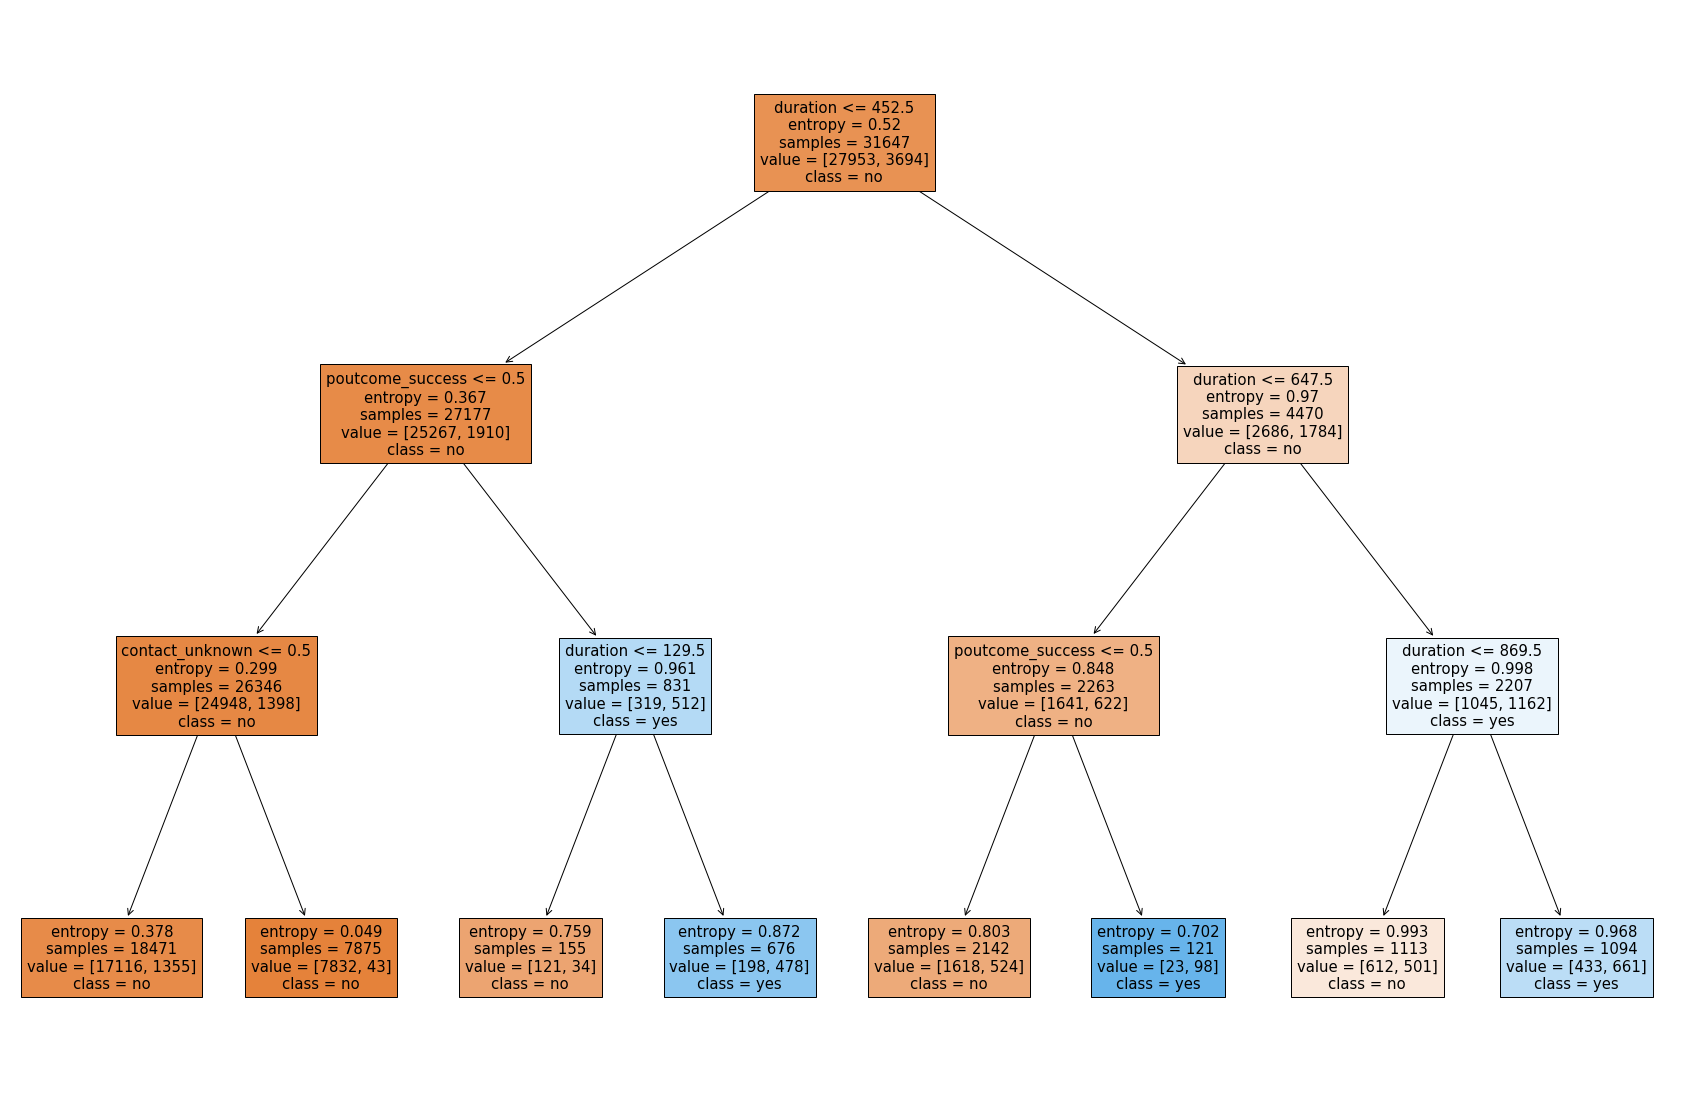

In [ ]:
# Plot the tree (0.5 points)
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model, 
               feature_names=list(predictors_train.columns),  
               class_names=['no','yes'],
               filled=True)

In [ ]:
# Make predictions on testing and testing data (0.5 points)
prediction_on_train = model.predict(predictors_train)
prediction_on_test = model.predict(predictors_test)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


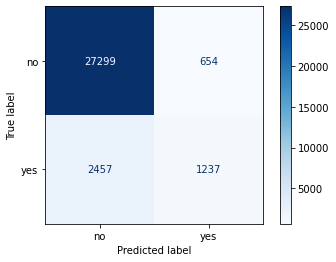

In [ ]:
# Examine the evaluation results on training data: confusion_matrix (0.5 points)
plot_confusion_matrix(model, predictors_train, target_train, cmap=plt.cm.Blues, values_format='d')

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


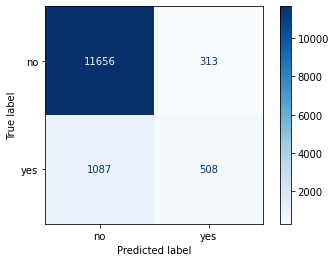

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix (0.5 points)
plot_confusion_matrix(model, predictors_test, target_test, cmap=plt.cm.Blues, values_format='d')

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score (0.5 points)
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

          no       0.92      0.98      0.95     27953
         yes       0.65      0.33      0.44      3694

    accuracy                           0.90     31647
   macro avg       0.79      0.66      0.69     31647
weighted avg       0.89      0.90      0.89     31647



In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score (0.5 points)
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          no       0.91      0.97      0.94     11969
         yes       0.62      0.32      0.42      1595

    accuracy                           0.90     13564
   macro avg       0.77      0.65      0.68     13564
weighted avg       0.88      0.90      0.88     13564



Q4. Based on the performances of Decision Tree model on **testing data**. Please answer the following questions <br>
4.1. How many client subscribed a term deposit in the testing data? (0.5 points)<br>
4.2. Among the customers who are predicted to subscribe a term deposit, how many of them didn't subscribe a term deposit? (0.5 points)<br>
4.3. How many customers are predicted correctly by this model? (0.5 points)<br>
4.4. If the decision tree model predict a customer will subscribe a term deposit, what is the probability of such prediction is correct? (0.5 points)<br>
4.5. Does the model has a better performance on the majority or minority class? (0.5 points)<br>
<br>
4.1. 1,595<br>
4.2. 313<br>
4.3. 11,656+508 = 12,164<br>
4.4. 62%<br>
4.5. Better performance on the majority class due to the higher F-measure value on the "No" class.<br>

## Part 2. Numeric Prediction with Game Sale data <br>
Video games are a billion-dollar business and have been for many years. In 2016, the video game market in the United States was valued at 17.68 billion U.S. dollars. That same year U.S. consumers were said to spend roughly double the amount on gaming content, hardware and accessories. What is important is that the first generation of gamers is now grown up with significant spending power; therefore, despite high penetration rates among kids, video games can no longer be considered solely a child's play. In fact, it was found that video gaming is gaining on popularity among the seniors in the United States.<br>
<br>
This data provides video sales information together with game scores and ratings. Our task is to predict game sales by given the information of each game.
<br><br>
VARIABLE DESCRIPTIONS:<br>
<br>
Name: Game name<br>
Platform: Platform of the games release (i.e. PC,PS4, etc.)<br>
Genre: Genre of the game<br>
Global_Sales: Total worldwide sales (in millions)<br>
Critic_Score: Aggregate score compiled by Metacritic staff<br>
Critic_Count: The number of critics used in coming up with the Critic_score <br>
User_Score: Score by Metacritic's subscribers<br>
User_Count: Number of users who gave the user_score<br>
Rating: The ESRB ratings<br>
<br>
**Target variable: Global_Sales**

### 1.Upload and clean data (0.5 points)

In [ ]:
# Import libraries
! pip install regressors
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from regressors import stats
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as plt

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Read data
Sales = pd.read_csv('/content/drive/MyDrive/DL_data/sales.csv')
Sales

,Name,Platform,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,The Legend of Zelda: Twilight Princess,Wii,Action,7.15,95,73,89,1658,T
1,Super Smash Bros. Melee,GC,Fighting,7.07,92,38,90,568,T
2,Medal of Honor: Frontline,PS2,Shooter,6.83,88,29,84,135,T
3,Uncharted 3: Drake's Deception,PS3,Action,6.74,92,97,82,3712,T
4,Uncharted 2: Among Thieves,PS3,Action,6.66,96,105,87,5187,T
...,...,...,...,...,...,...,...,...,...
6937,Act of Aggression,PC,Strategy,0.01,71,37,70,93,missing
6938,Root Letter,PS4,Adventure,0.01,69,13,74,11,missing
6939,Colin McRae Rally 04,PC,Racing,0.01,87,6,71,44,missing
6940,Prison Architect,XOne,Action,0.01,74,13,66,7,missing


In [ ]:
# Examine the number of rows and cols
Sales.shape

(6942, 9)

In [ ]:
# Drop (remove) the Name column
Sales = Sales.drop(['Name'],axis=1)

**Q5. Explain why we remove the name column? (0.5 points)**<br>
The Name column doesn't provide useful information for predicting Global_Sales. And we will have too many dummy variables if Name column is included.

In [ ]:
# Examine variable type
Sales.dtypes

Platform         object
Genre            object
Global_Sales    float64
Critic_Score      int64
Critic_Count      int64
User_Score        int64
User_Count        int64
Rating           object
dtype: object

In [ ]:
# Change categorical variables to "category"
Sales['Platform'] = Sales['Platform'].astype('category')
Sales['Genre'] = Sales['Genre'].astype('category')
Sales['Rating'] = Sales['Rating'].astype('category')

In [ ]:
# Examine variable type again
Sales.dtypes

Platform        category
Genre           category
Global_Sales     float64
Critic_Score       int64
Critic_Count       int64
User_Score         int64
User_Count         int64
Rating          category
dtype: object

### 2.Data partitioning and inspection code (3.5 points)

In [ ]:
# Create dummy variables for Platform, Genre, and Rating	(1 point)
Sales = pd.get_dummies(Sales, columns=['Platform','Genre','Rating'], drop_first=True)
Sales

,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,...,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Rating_E10+,Rating_M,Rating_T,Rating_missing
0,7.15,95,73,89,1658,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,7.07,92,38,90,568,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,6.83,88,29,84,135,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,6.74,92,97,82,3712,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,6.66,96,105,87,5187,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6937,0.01,71,37,70,93,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
6938,0.01,69,13,74,11,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6939,0.01,87,6,71,44,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
6940,0.01,74,13,66,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Partition the data to predictors_train, predictors_test, target_train, and target_test. Set test_size=0.3 and random_state=0. (1.5 points)
target = Sales['Global_Sales']
predictors = Sales.drop(['Global_Sales'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(4859, 35) (2083, 35) (4859,) (2083,)


Text(0.5, 1.0, 'Histogram of Global_Sales in the training data set')

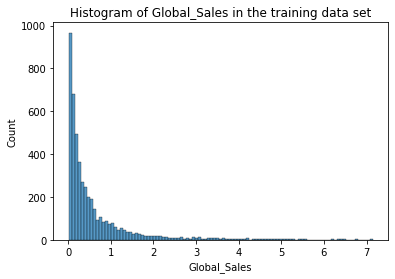

In [ ]:
# Examine the distribution of target variable for training data set (using the histplot function). (0.5 points)
snsplot = sns.histplot(data = target_train)
snsplot.set_title("Histogram of Global_Sales in the training data set")

Text(0.5, 1.0, 'Histogram of Global_Sales in the testing data set')

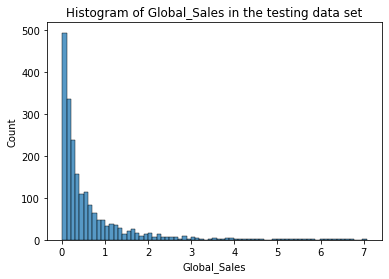

In [ ]:
# Examine the distribution of target variable for testing data set (using the histplot function). (0.5 points)
snsplot = sns.histplot(data = target_test)
snsplot.set_title("Histogram of Global_Sales in the testing data set")

### 3.Multiple Linear Regression model for predicting Global_Sales value. (6 points)

In [ ]:
# Build a multiple linear regression model with all predictors (1 point)
model_lr = linear_model.LinearRegression()
model_lr.fit(predictors_train, target_train)

LinearRegression()

In [ ]:
# Show the linear regression model summary (0.5 points)
predictor_names = predictors_train.columns.values
stats.summary(model_lr, predictors_train, target_train, predictor_names)

Residuals:
    Min     1Q  Median     3Q    Max
-5.9483 -0.189  0.1399 0.4107 3.8984


Coefficients:
                    Estimate  Std. Error  t value   p value
_intercept         -0.609791    0.082332  -7.4065  0.000000
Critic_Score        0.019093    0.000760  25.1327  0.000000
Critic_Count        0.013488    0.000650  20.7482  0.000000
User_Score         -0.006056    0.000693  -8.7388  0.000000
User_Count          0.000423    0.000022  19.3125  0.000000
Platform_DC        -0.197575    0.267270  -0.7392  0.459801
Platform_DS         0.233791    0.060094   3.8904  0.000101
Platform_GBA        0.157438    0.074952   2.1005  0.035736
Platform_GC         0.007615    0.066371   0.1147  0.908657
Platform_PC        -0.549960    0.056243  -9.7783  0.000000
Platform_PS         0.840254    0.090005   9.3356  0.000000
Platform_PS2        0.361549    0.046294   7.8098  0.000000
Platform_PS3        0.204838    0.051392   3.9858  0.000068
Platform_PS4       -0.028770    0.074552  -0.3859  0.699582

Q6. If Critic_Score is increased by 1 (and all the other variable values are held constant), Global_Sales will increase __?__ millions. (0.5 points)<br>
0.019093

Q7. If Critic_Count is increased by 1 (and all the other variable values are held constant), Global_Sales will increase __?__ millions. (0.5 points)<br>
0.013488

Q8. Are User_Score and User_Count important for predicting Global_Sales, and why? hint: using the p-value to determine the importance. (1 point)<br>
Yes, because User_Score and User_Count have small p values (lower than 0.05), which indicate these two variables are important for predicting Global_Sales.

Q9. What is the value of Multiple R-squared? Interpret the meaning of Multiple R-squared value. (1 point)<br>
R-squared:  0.30728<br>
All predictors together can explain about 30.728% of the variation of the target variable.


In [ ]:
# Make predictions on training and testing data (0.5 points)
prediction_on_train = model_lr.predict(predictors_train)
prediction_on_test = model_lr.predict(predictors_test)

In [ ]:
# Examine the evaluation results on training data: MAE and RMSE (0.5 points)
MAE = mean_absolute_error(target_train, prediction_on_train)
RMSE = mean_squared_error(target_train, prediction_on_train, squared=False)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.48522991618384176
RMSE: 0.7753041827871554


In [ ]:
# Examine the evaluation results on testing data: MAE and RMSE (0.5 points)
MAE = mean_absolute_error(target_test, prediction_on_test)
RMSE = mean_squared_error(target_test, prediction_on_test, squared=False)
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.4945490418627451
RMSE: 0.7793835143830433
